---
### Sobre a Fonte dos Dados e Licenciamento

Este projeto utiliza o **Heart Failure Prediction Dataset**, compilado e disponibilizado por **fedesoriano** na plataforma Kaggle.

* **Licença de Uso:** Open Database License (ODbL) v1.0.
* **Origem do Dataset:** A base combina 5 conjuntos de dados cardíacos populares (Cleveland, húngaro, Suíça, Long Beach VA e Statlog) contendo 11 feições clínicas relevantes.
* **Uso e Modificações:** Os dados foram limpos e formatados para esta análise. Conforme a regra *Share-Alike* da licença ODbL, o conjunto de dados processado está disponível publicamente sob os mesmos termos de licença no nosso repositório.
---

# --- Célula 1: Importação de Bibliotecas ---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Célula 2: Carregamento e Visão Geral ---

In [ ]:
df = pd.read_csv("heart.csv")

print(f"Formato do Dataset: {df.shape}") # (918, 12)
display(df.head())

### **2. Limpeza e Pré-processamento (Data Cleaning)**
# Identificamos inconsistências médicas críticas que precisam ser tratadas antes da análise estatística.


Formato do Dataset: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


# --- Célula 3: Investigação de Inconsistências (Data Discovery) ---

In [ ]:
# Usamos o describe() para analisar os limites (mínimos e máximos) das variáveis numéricas
display(df[['RestingBP', 'Cholesterol']].describe())

# Detalhando o impacto dos valores zerados no Colesterol
qtd_zeros_col = (df['Cholesterol'] == 0).sum()
pct_zeros_col = (qtd_zeros_col / len(df)) * 100
print(f"\nAlerta de Qualidade: {qtd_zeros_col} pacientes com Colesterol zerado ({pct_zeros_col:.2f}% da base).")

# Detalhando a Pressão Arterial
qtd_zeros_bp = (df['RestingBP'] == 0).sum()
print(f"Alerta de Qualidade: {qtd_zeros_bp} paciente com Pressão Arterial em Repouso igual a 0.")


,RestingBP,Cholesterol
count,918.000000,918.000000
mean,132.396514,198.799564
std,18.514154,109.384145
min,0.000000,0.000000
25%,120.000000,173.250000
50%,130.000000,223.000000
75%,140.000000,267.000000
max,200.000000,603.000000



Alerta de Qualidade: 172 pacientes com Colesterol zerado (18.74% da base).
Alerta de Qualidade: 1 paciente com Pressão Arterial em Repouso igual a 0.


# --- Célula 4: Tratamento de Valores Inconsistentes ---

In [ ]:
# 1. RestingBP: Remover registro com pressão 0 (clinicamente impossível)
df = df[df['RestingBP'] != 0].copy()

# 2. Cholesterol: Imputar os 18.74% de dados zerados pela mediana baseada no diagnóstico
median_heart_disease = df[(df['HeartDisease'] == 1) & (df['Cholesterol'] != 0)]['Cholesterol'].median()
median_normal = df[(df['HeartDisease'] == 0) & (df['Cholesterol'] != 0)]['Cholesterol'].median()

df.loc[(df['HeartDisease'] == 1) & (df['Cholesterol'] == 0), 'Cholesterol'] = median_heart_disease
df.loc[(df['HeartDisease'] == 0) & (df['Cholesterol'] == 0), 'Cholesterol'] = median_normal

print("\nLimpeza concluída: Pressão zero removida e Colesterol zero imputado.")


Limpeza concluída: Pressão zero removida e Colesterol zero imputado.


# --- Célula 5: Distribuição de Idade e Variável Alvo ---

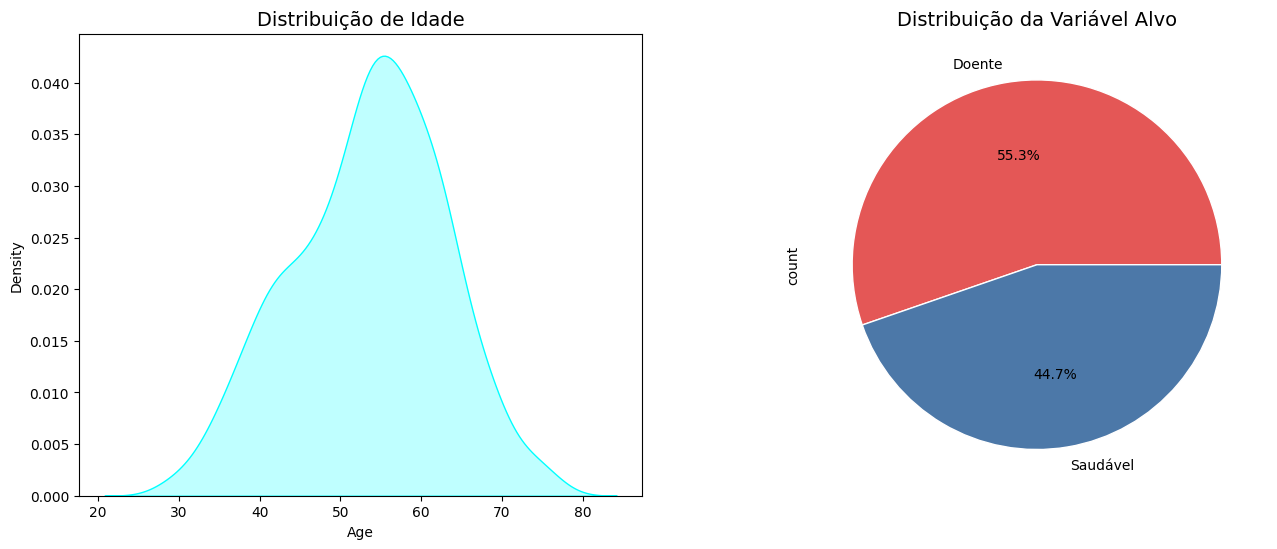

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição de Idade
sns.kdeplot(data=df, x="Age", fill=True, color="cyan", ax=ax[0])
ax[0].set_title("Distribuição de Idade", fontsize=14)

# Distribuição da Variável Alvo

# Proporção de Doenças Cardíacas
df["HeartDisease"].value_counts().plot.pie(
    autopct="%1.1f%%", colors=["#E45756", "#4C78A8"],
    labels=["Doente", "Saudável"], ax=ax[1], wedgeprops={"edgecolor": "white"}
)
ax[1].set_title("Distribuição da Variável Alvo", fontsize=14)
plt.show()

### **4. Análise Bivariada: Relacionando com HeartDisease**
# Aqui buscamos os padrões que diferenciam pacientes saudáveis de doentes.


# --- Célula 6: Atributos Categóricos vs Doença ---

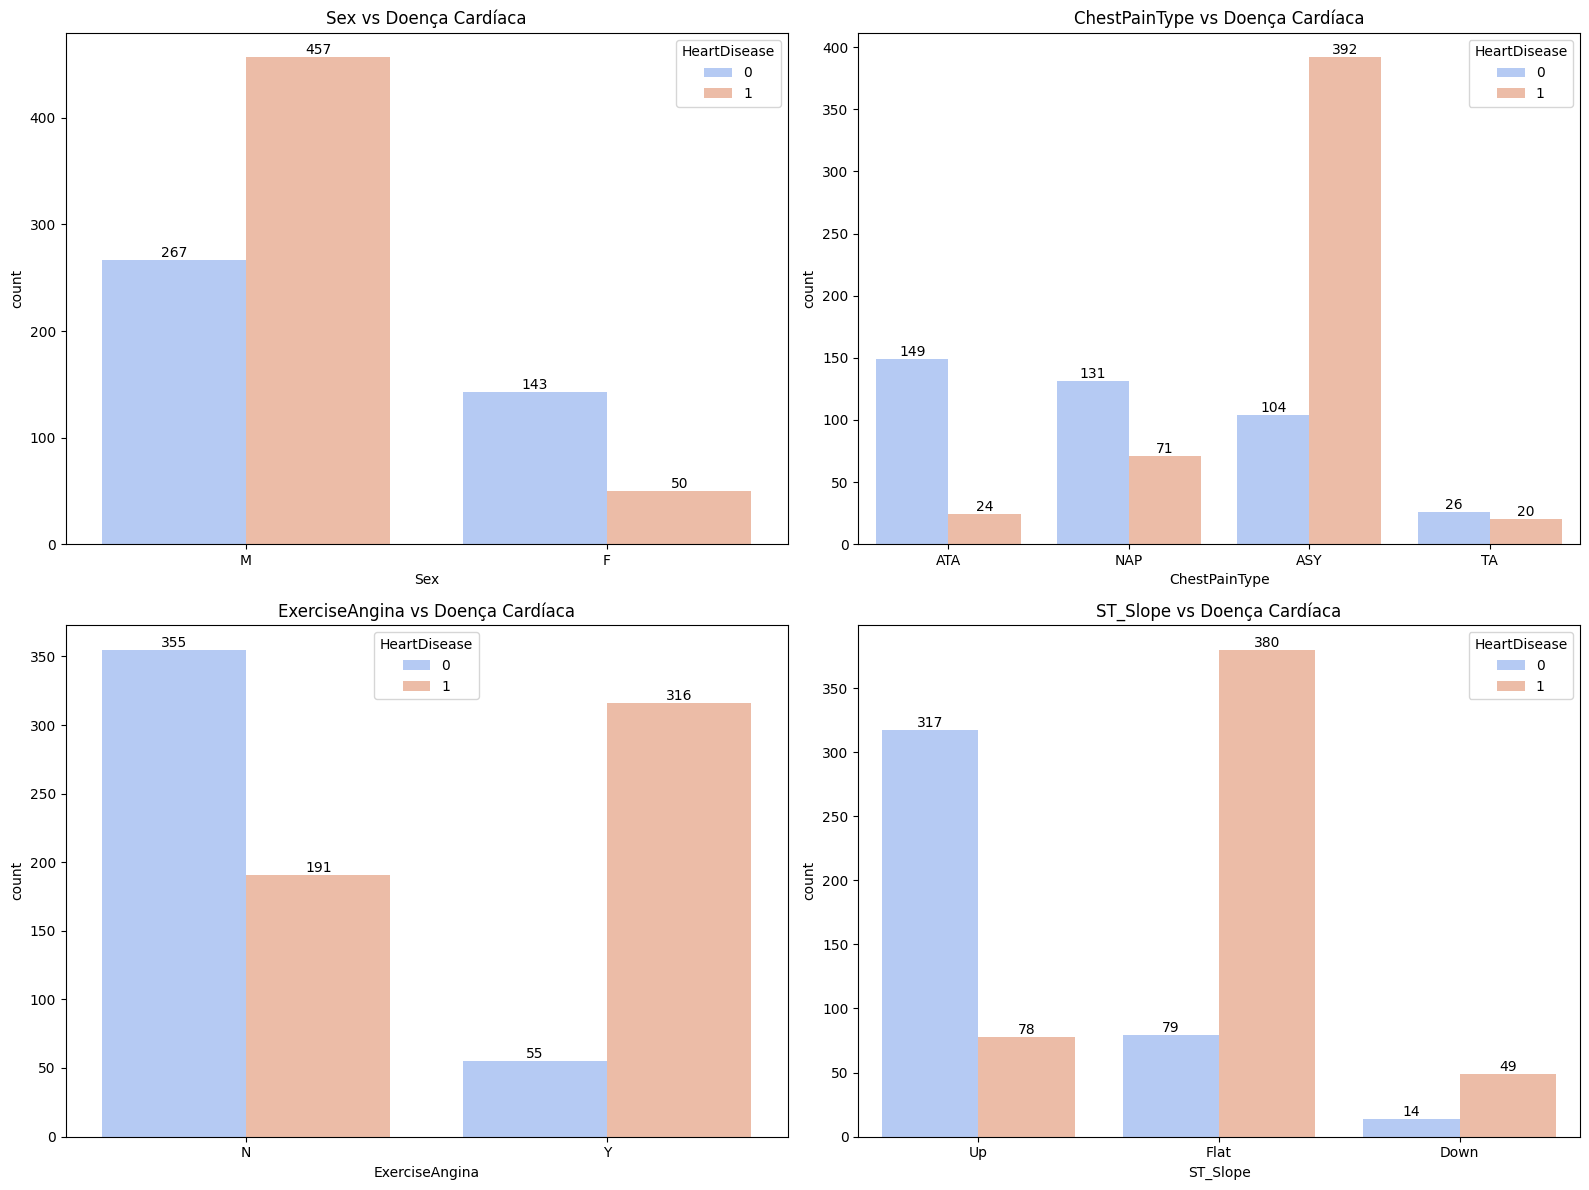

In [ ]:
categorical_cols = ['Sex', 'ChestPainType', 'ExerciseAngina', 'ST_Slope']

plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    ax = sns.countplot(data=df, x=col, hue='HeartDisease', palette='coolwarm')
    plt.title(f'{col} vs Doença Cardíaca')
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

### **5. Análise de Preditores Numéricos**

**Insights Críticos para o Vídeo:**
*   **Gênero:** Homens apresentam prevalência muito superior de doenças cardíacas neste dataset.
*   **Tipo de Dor:** A dor assintomática (**ASY**) é o maior indicador de diagnóstico positivo, sugerindo perigo silencioso.
*   **Angina de Exercício:** Quem apresenta angina ao se exercitar tem probabilidade drasticamente maior de ter a doença.

# --- Célula 7: Distribuição Numérica por Diagnóstico ---

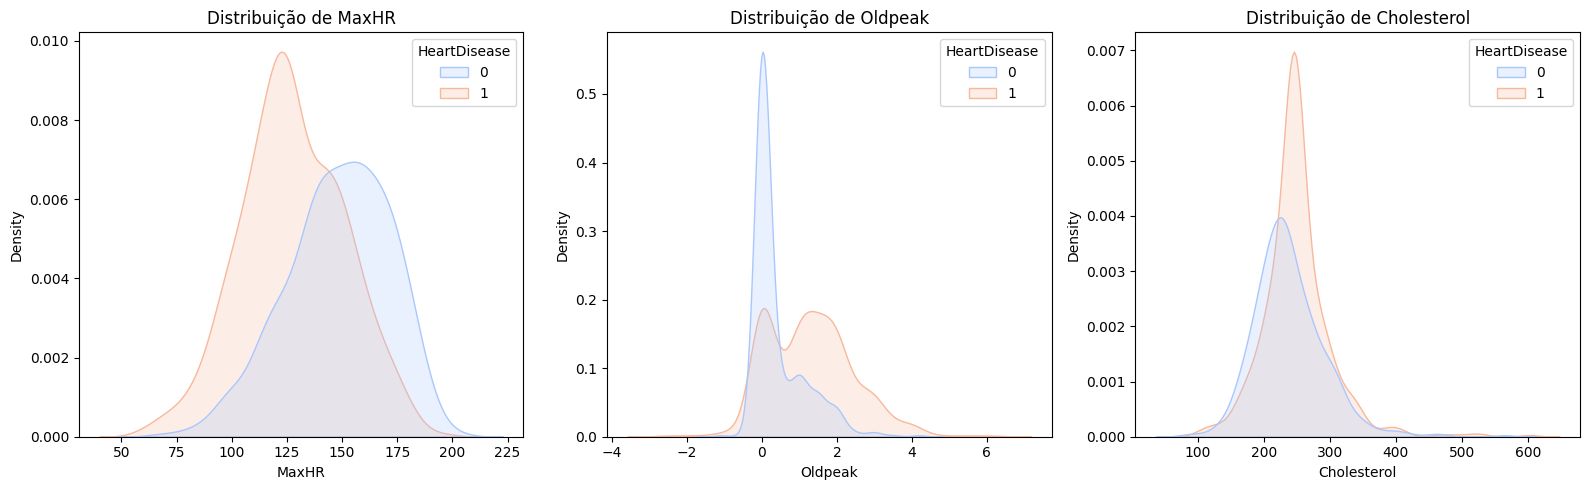

In [ ]:
numeric_cols = ['MaxHR', 'Oldpeak', 'Cholesterol']

plt.figure(figsize=(16, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.kdeplot(data=df, x=col, hue='HeartDisease', fill=True, palette='coolwarm')
    plt.title(f'Distribuição de {col}')

plt.tight_layout()
plt.show()

### **6. Correlação e Conclusão**


**Insights Técnicos:**
*   **MaxHR (Freq. Cardíaca Máxima):** Pessoas saudáveis atingem picos maiores (>150 bpm). Pacientes doentes concentram-se em valores menores (~120 bpm).
*   **Oldpeak:** Valores elevados de depressão de ST aumentam agudamente o risco de insuficiência cardíaca.

# --- Célula 8: Heatmap de Correlação ---

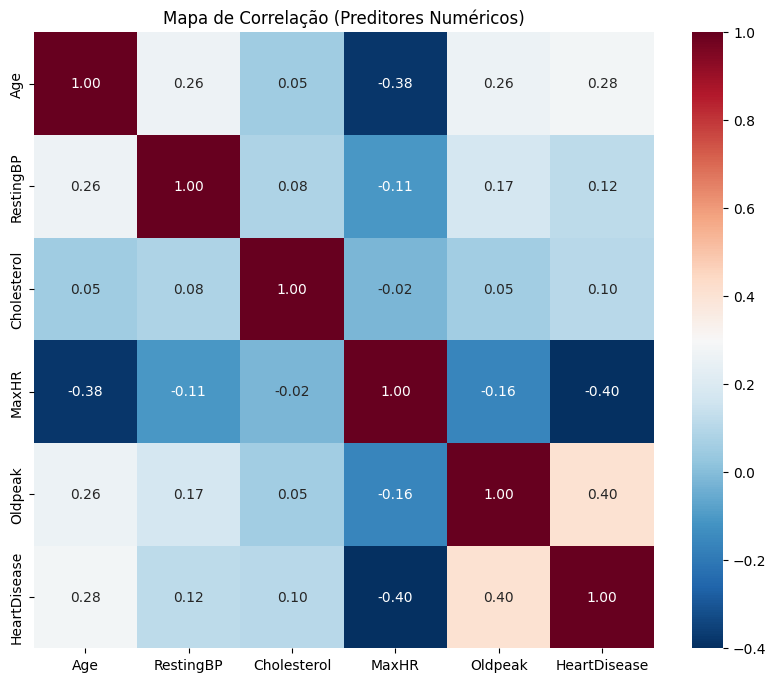

In [ ]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Mapa de Correlação (Preditores Numéricos)')
plt.show()

**Resumo da EDA para o canal Insight em Dados:**
1.  **Fortes Preditores:** `Oldpeak` (correlação positiva de 0.40) e `MaxHR` (correlação negativa de -0.40) são os sinais clínicos mais robustos.
2.  **Idade:** O risco sobe consideravelmente após os 55 anos.
3.  **Variáveis Complexas:** Colesterol e Pressão Arterial mostram correlações individuais fracas no heatmap, sugerindo que seu impacto pode ser não-linear ou depender de outros fatores combinados.

Este notebook fornece uma base sólida para qualquer modelo de Machine Learning, como o **Voting Classifier**, que pode atingir até **87.5% de acurácia** utilizando esses dados limpos.